# ECG Arrhythmia Classification

In [4]:
from google.colab import ai
response = ai.generate_text("What are different types of cardiac arrhythmias, and why their automatic prediction is important? What are specific types of arrhythmias present in Physionet's MIT-BIH Arrhythmia dataset?")
response

'Cardiac arrhythmias are abnormalities in the heart\'s electrical activity, leading to an irregular, too fast, or too slow heartbeat. They can range from benign to life-threatening.\n\n## Different Types of Cardiac Arrhythmias\n\nArrhythmias can be classified in various ways, often based on their origin within the heart (atria or ventricles), their rate (tachycardia or bradycardia), and their regularity.\n\nHere are some common types:\n\n### 1. By Heart Rate:\n\n*   **Tachycardia:** A heart rate that is too fast (typically over 100 beats per minute at rest).\n*   **Bradycardia:** A heart rate that is too slow (typically under 60 beats per minute at rest).\n\n### 2. By Origin in the Heart:\n\n#### A. Supraventricular Arrhythmias (Originating above the ventricles, in the atria or AV node):\n\n*   **Sinus Tachycardia:** A faster-than-normal heart rate originating from the sinus node. Often a normal response to exercise, stress, fever, etc., but can be inappropriate.\n*   **Sinus Bradycard

In [ ]:
'''Follow this cell sequentially, if you want to run the code in this notebook on your local machine. It will set up a new python environment and install the necessary packages. Make sure to activate the environment before running the notebook.

   AND you can ignore this, if you use Colab/Kaggle platform.
'''

### Make a new local python environment and install the required packages using the command below. This will ensure that you have all the necessary dependencies to run the code in this notebook.
#!python3 -m venv myenv
## source myenv/bin/activate
### Initiate a jupyter kernel
# !pip install ipykernel
# !python3 -m ipykernel install --user --name=myenv
# !pip install -r requirements.txt

In [ ]:
## Load data (use Kaggle preprocessed or your own)
## Example: download from https://www.kaggle.com/shayanfazeli/heartbeat

In [2]:
!unzip archive.zip -d data/

Archive:  archive.zip
  inflating: data/mitbih_test.csv    
  inflating: data/mitbih_train.csv   
  inflating: data/ptbdb_abnormal.csv  
  inflating: data/ptbdb_normal.csv   


In [ ]:
# import tensorflow as tf
# import sys

# # 1. Check if MPS is available
# print("Num GPUs Available: ", len(tf.config.list_physical_devices('GPU')))
# print("TensorFlow version:", tf.__version__)

# # Detect and configure GPU (MPS on Apple Silicon)
# gpus = tf.config.list_physical_devices('GPU')

# if gpus:
#     try:
#         # Use the first (and usually only) GPU
#         tf.config.set_visible_devices(gpus[0], 'GPU')
#         # Enable memory growth (recommended on Apple Silicon)
#         tf.config.experimental.set_memory_growth(gpus[0], True)
#         print("→ Using MPS GPU acceleration")
#     except RuntimeError as e:
#         print("→ GPU configuration failed:", e)
#         print("→ Falling back to CPU")
# else:
#     print("→ No GPU (MPS) detected → using CPU")

# # Quick confirmation
# print("Is GPU available?", tf.test.is_gpu_available())
# print("Current devices:", tf.config.list_logical_devices())

# # Optional: force a small operation on GPU to verify
# with tf.device('/GPU:0' if gpus else '/CPU:0'):
#     a = tf.random.normal([1000, 1000])
#     b = tf.random.normal([1000, 1000])
#     c = tf.matmul(a, b)
#     print("Matrix multiplication device:", c.device)
# # print(c)

Instructions for updating:
Use `tf.config.list_physical_devices('GPU')` instead.


Num GPUs Available:  1
TensorFlow version: 2.19.0
→ Using MPS GPU acceleration
Is GPU available? True
Current devices: [LogicalDevice(name='/device:CPU:0', device_type='CPU'), LogicalDevice(name='/device:GPU:0', device_type='GPU')]
Matrix multiplication device: /job:localhost/replica:0/task:0/device:GPU:0


TensorFlow: 2.19.0
GPU Available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
Loading data...
Original X_train shape: (87554, 187)
Original X_test shape: (21892, 187)
Applying bandpass filter...
Extracting handcrafted features...
Normalizing data...
Train class counts: [72471  2223  5788   641  6431]
Test  class counts: [18118   556  1448   162  1608]

Applying SMOTE-Tomek for balanced dataset...
After augmentation: 483129 samples


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ signal_input        │ (None, 187, 1)    │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d (Conv1D)     │ (None, 187, 32)   │        512 │ signal_input[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 187, 32)   │        128 │ conv1d[0][0]      │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation          │ (None, 187, 32)   │          0 │ batch_normalizat… │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling1d       │ (None, 93, 32)    │          0 │ activation[0][0]  │
│ (MaxPooling1D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_1 (Conv1D)   │ (None, 93, 64)    │     22,592 │ max_pooling1d[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 93, 64)    │        256 │ conv1d_1[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_1        │ (None, 93, 64)    │          0 │ batch_normalizat… │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 93, 64)    │          0 │ activation_1[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_2 (Conv1D)   │ (None, 93, 64)    │     45,120 │ dropout[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 93, 64)    │        256 │ conv1d_2[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_3 (Conv1D)   │ (None, 93, 64)    │      2,112 │ max_pooling1d[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 93, 64)    │          0 │ batch_normalizat… │
│                     │                   │            │ conv1d_3[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_2        │ (None, 93, 64)    │          0 │ add[0][0]         │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling1d_1     │ (None, 46, 64)    │          0 │ activation_2[0][… │
│ (MaxPooling1D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_4 (Conv1D)   │ (None, 46, 128)   │     57,472 │ max_pooling1d_1[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 46, 128)   │        512 │ conv1d_4[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_3        │ (None, 46, 128)   │          0 │ batch_normalizat… │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 46, 128)   │          0 │ activation_3[0][

 Total params: 1,610,021 (6.14 MB)

 Trainable params: 1,607,333 (6.13 MB)

...

6040/6040 ━━━━━━━━━━━━━━━━━━━━ 62s 10ms/step - accuracy: 0.9942 - f1_score: 0.9939 - loss: 0.4386 - sensitivity: 0.9922 - specificity: 0.9989 - val_accuracy: 0.9962 - val_f1_score: 0.9964 - val_loss: 0.4233 - val_sensitivity: 0.9956 - val_specificity: 0.9993 - learning_rate: 0.0010 - lr: 0.0010
Epoch 36/100
6040/6040 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9946 - f1_score: 0.9944 - loss: 0.4374 - sensitivity: 0.9928 - specificity: 0.9990
Epoch 36: val_f1_score did not improve from 0.99636
6040/6040 ━━━━━━━━━━━━━━━━━━━━ 61s 10ms/step - accuracy: 0.9946 - f1_score: 0.9944 - loss: 0.4374 - sensitivity: 0.9928 - specificity: 0.9990 - val_accuracy: 0.9944 - val_f1_score: 0.9943 - val_loss: 0.4279 - val_sensitivity: 0.9932 - val_specificity: 0.9988 - learning_rate: 0.0010 - lr: 0.0010
Epoch 37/100
6037/6040 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9949 - f1_score: 0.9946 - loss: 0.4368 - sensitivity: 0.9930 - specificity: 0.9991
Epoch 37: val_f1_score did not improve from 0.9963

6040/6040 ━━━━━━━━━━━━━━━━━━━━ 78s 11ms/step - accuracy: 0.9951 - f1_score: 0.9948 - loss: 0.4352 - sensitivity: 0.9934 - specificity: 0.9991 - val_accuracy: 0.9969 - val_f1_score: 0.9969 - val_loss: 0.4203 - val_sensitivity: 0.9963 - val_specificity: 0.9994 - learning_rate: 0.0010 - lr: 0.0010
Epoch 42/100
6037/6040 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.9950 - f1_score: 0.9947 - loss: 0.4353 - sensitivity: 0.9932 - specificity: 0.9991
Epoch 42: val_f1_score did not improve from 0.99692
6040/6040 ━━━━━━━━━━━━━━━━━━━━ 63s 10ms/step - accuracy: 0.9950 - f1_score: 0.9947 - loss: 0.4353 - sensitivity: 0.9932 - specificity: 0.9991 - val_accuracy: 0.9962 - val_f1_score: 0.9962 - val_loss: 0.4233 - val_sensitivity: 0.9955 - val_specificity: 0.9992 - learning_rate: 0.0010 - lr: 0.0010
Epoch 43/100
6037/6040 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9953 - f1_score: 0.9950 - loss: 0.4346 - sensitivity: 0.9935 - specificity: 0.9991
Epoch 43: val_f1_score did not improve from 0.996

6040/6040 ━━━━━━━━━━━━━━━━━━━━ 62s 10ms/step - accuracy: 0.9957 - f1_score: 0.9953 - loss: 0.4330 - sensitivity: 0.9940 - specificity: 0.9992 - val_accuracy: 0.9971 - val_f1_score: 0.9970 - val_loss: 0.4197 - val_sensitivity: 0.9965 - val_specificity: 0.9994 - learning_rate: 0.0010 - lr: 0.0010
Epoch 52/100
6037/6040 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9957 - f1_score: 0.9954 - loss: 0.4333 - sensitivity: 0.9939 - specificity: 0.9992
Epoch 52: val_f1_score improved from 0.99704 to 0.99708, saving model to best_model.h5


6040/6040 ━━━━━━━━━━━━━━━━━━━━ 62s 10ms/step - accuracy: 0.9957 - f1_score: 0.9954 - loss: 0.4333 - sensitivity: 0.9939 - specificity: 0.9992 - val_accuracy: 0.9971 - val_f1_score: 0.9971 - val_loss: 0.4186 - val_sensitivity: 0.9965 - val_specificity: 0.9994 - learning_rate: 0.0010 - lr: 0.0010
Epoch 53/100
6035/6040 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9958 - f1_score: 0.9955 - loss: 0.4323 - sensitivity: 0.9941 - specificity: 0.9992
Epoch 53: val_f1_score did not improve from 0.99708
6040/6040 ━━━━━━━━━━━━━━━━━━━━ 63s 10ms/step - accuracy: 0.9958 - f1_score: 0.9955 - loss: 0.4323 - sensitivity: 0.9941 - specificity: 0.9992 - val_accuracy: 0.9968 - val_f1_score: 0.9967 - val_loss: 0.4195 - val_sensitivity: 0.9960 - val_specificity: 0.9994 - learning_rate: 0.0010 - lr: 0.0010
Epoch 54/100
6037/6040 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9956 - f1_score: 0.9952 - loss: 0.4325 - sensitivity: 0.9939 - specificity: 0.9992
Epoch 54: val_f1_score did not improve from 0.9970

6040/6040 ━━━━━━━━━━━━━━━━━━━━ 62s 10ms/step - accuracy: 0.9956 - f1_score: 0.9953 - loss: 0.4320 - sensitivity: 0.9940 - specificity: 0.9992 - val_accuracy: 0.9975 - val_f1_score: 0.9975 - val_loss: 0.4172 - val_sensitivity: 0.9970 - val_specificity: 0.9995 - learning_rate: 0.0010 - lr: 0.0010
Epoch 60/100
6037/6040 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9961 - f1_score: 0.9959 - loss: 0.4305 - sensitivity: 0.9946 - specificity: 0.9993
Epoch 60: val_f1_score did not improve from 0.99753
6040/6040 ━━━━━━━━━━━━━━━━━━━━ 62s 10ms/step - accuracy: 0.9961 - f1_score: 0.9959 - loss: 0.4305 - sensitivity: 0.9946 - specificity: 0.9993 - val_accuracy: 0.9965 - val_f1_score: 0.9965 - val_loss: 0.4191 - val_sensitivity: 0.9958 - val_specificity: 0.9993 - learning_rate: 0.0010 - lr: 0.0010
Epoch 61/100
6037/6040 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9960 - f1_score: 0.9957 - loss: 0.4310 - sensitivity: 0.9943 - specificity: 0.9993
Epoch 61: val_f1_score did not improve from 0.9975

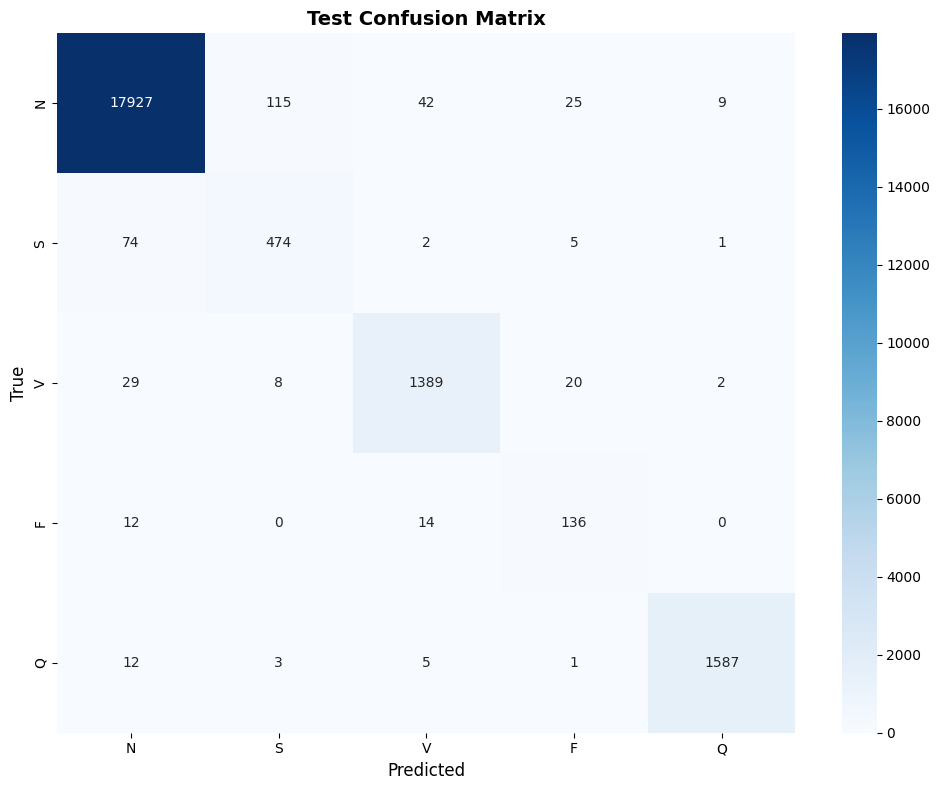

Weighted ROC-AUC: 0.9928

Per-Class Performance:
N: Accuracy = 0.9855
S: Accuracy = 0.9905
V: Accuracy = 0.9944
F: Accuracy = 0.9965
Q: Accuracy = 0.9985


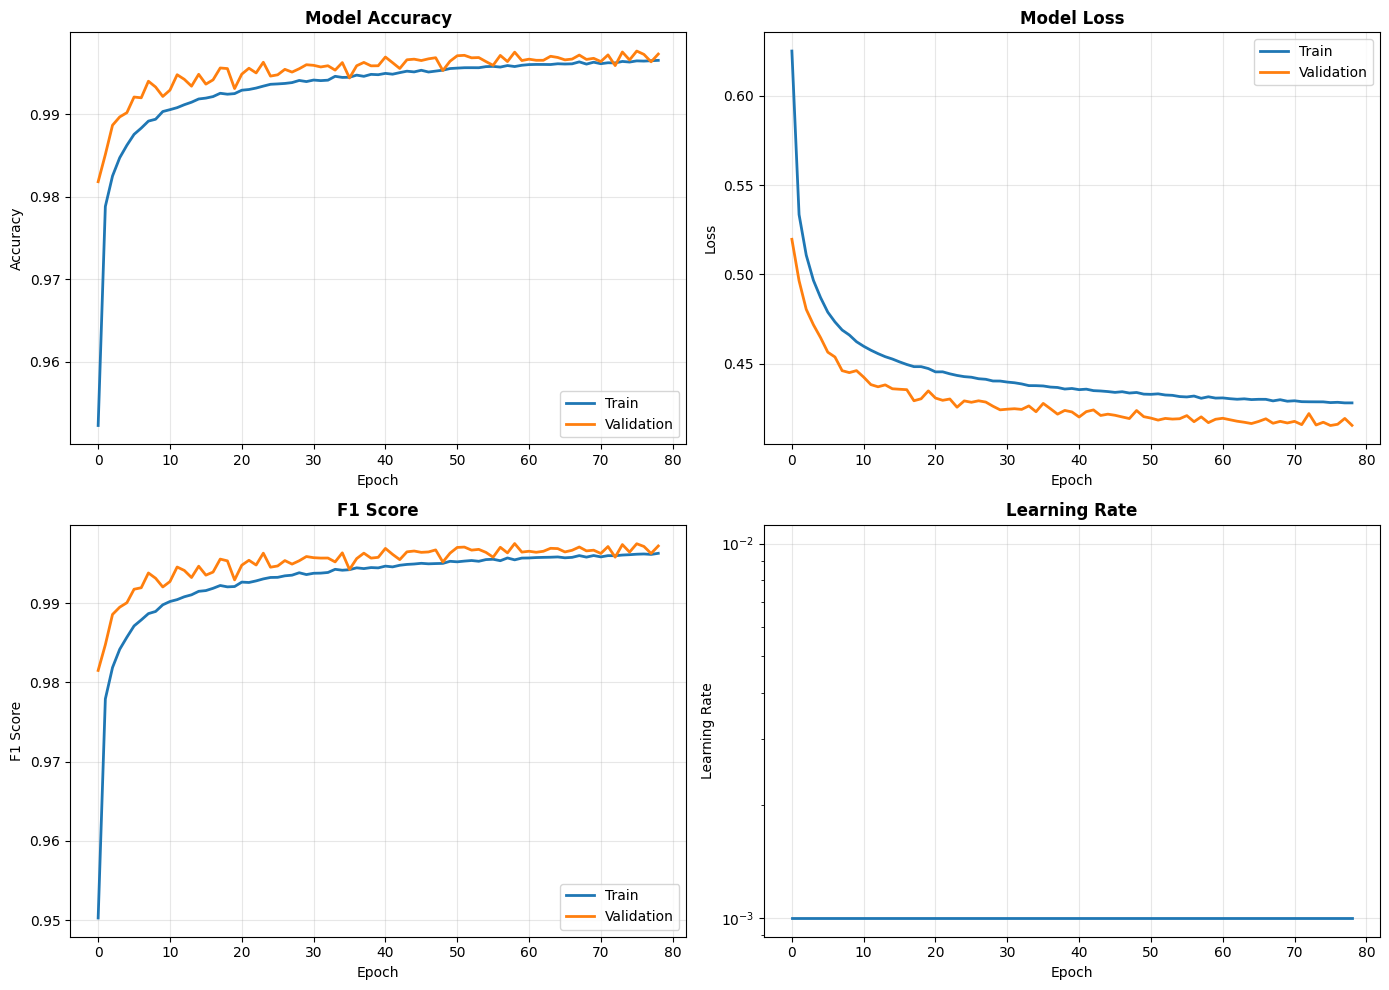


Total misclassified samples: 379


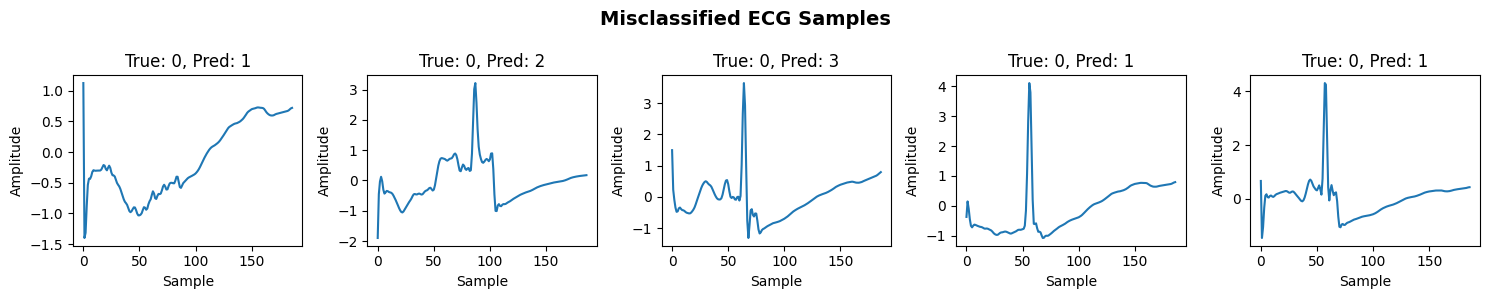


Model saved as 'ecg_arrhythmia_model_final.h5'


In [3]:
# ────────────────────────────────────────────────
# ECG Arrhythmia Classification – MIT-BIH Dataset
# Enhanced Version with Better Performance (FIXED)
# ────────────────────────────────────────────────

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import signal
from scipy.stats import skew, kurtosis

from sklearn.metrics import confusion_matrix, classification_report, roc_auc_score
from sklearn.utils.class_weight import compute_class_weight
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

import tensorflow as tf
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import (
    Conv1D, MaxPooling1D, Flatten, Dense, Dropout,
    BatchNormalization, GlobalAveragePooling1D, Input,
    Add, Activation, Concatenate
)
from tensorflow.keras.optimizers import Adam # Changed from .legacy import Adam
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint, Callback
from tensorflow.keras.regularizers import l2
from tensorflow.keras import backend as K

import warnings
warnings.filterwarnings('ignore')

print("TensorFlow:", tf.__version__)
print("GPU Available:", tf.config.list_physical_devices('GPU'))

# ────────────────────────────────────────────────
# Custom Metrics & Loss Functions
# ────────────────────────────────────────────────

def sensitivity(y_true, y_pred):
    """Sensitivity (Recall) metric"""
    y_true = K.cast(y_true, 'float32')
    y_pred = K.cast(y_pred, 'float32')
    true_positives = K.sum(K.round(K.clip(y_true * y_pred, 0, 1)))
    possible_positives = K.sum(K.round(K.clip(y_true, 0, 1)))
    return true_positives / (possible_positives + K.epsilon())

def specificity(y_true, y_pred):
    """Specificity metric"""
    y_true = K.cast(y_true, 'float32')
    y_pred = K.cast(y_pred, 'float32')
    true_negatives = K.sum(K.round(K.clip((1 - y_true) * (1 - y_pred), 0, 1)))
    possible_negatives = K.sum(K.round(K.clip(1 - y_true, 0, 1)))
    return true_negatives / (possible_negatives + K.epsilon())

def f1_score(y_true, y_pred):
    """F1 Score metric"""
    y_true = K.cast(y_true, 'float32')
    y_pred = K.cast(y_pred, 'float32')
    true_positives = K.sum(K.round(K.clip(y_true * y_pred, 0, 1)))
    predicted_positives = K.sum(K.round(K.clip(y_pred, 0, 1)))
    possible_positives = K.sum(K.round(K.clip(y_true, 0, 1)))

    precision = true_positives / (predicted_positives + K.epsilon())
    recall = true_positives / (possible_positives + K.epsilon())

    return 2 * ((precision * recall) / (precision + recall + K.epsilon()))

# ────────────────────────────────────────────────
# Custom Callback for Learning Rate Logging
# ────────────────────────────────────────────────

class LRCallback(Callback):
    """Custom callback to log learning rate"""
    def on_epoch_end(self, epoch, logs=None):
        logs = logs or {}
        logs['lr'] = K.get_value(self.model.optimizer.learning_rate)

# ────────────────────────────────────────────────
# Advanced Preprocessing
# ────────────────────────────────────────────────

def add_noise_augmentation(X, y, noise_factor=0.01, num_augmented=None):
    """Add Gaussian noise for data augmentation"""
    if num_augmented is None:
        num_augmented = len(X) // 3

    indices = np.random.choice(len(X), num_augmented, replace=False)
    X_noisy = X[indices].copy()
    noise = np.random.normal(0, noise_factor, X_noisy.shape)
    X_noisy += noise

    return np.vstack([X, X_noisy]), np.hstack([y, y[indices]])

def extract_handcrafted_features(X):
    """Extract additional handcrafted features"""
    features = []

    for sample in X:
        sample_flat = sample.flatten()

        # Statistical features
        mean = np.mean(sample_flat)
        std = np.std(sample_flat)
        skewness = skew(sample_flat)
        kurt = kurtosis(sample_flat)

        # Morphological features
        peaks = signal.find_peaks(sample_flat, height=np.percentile(sample_flat, 75))[0]
        num_peaks = len(peaks)

        # Energy features
        energy = np.sum(sample_flat ** 2)

        features.append([mean, std, skewness, kurt, num_peaks, energy])

    return np.array(features)

def load_and_preprocess():
    print("Loading data...")
    # Load data
    df_train = pd.read_csv('data/mitbih_train.csv', header=None)
    df_test = pd.read_csv('data/mitbih_test.csv', header=None)

    # Basic preprocessing
    X_train = df_train.iloc[:, :-1].values.astype(np.float32)
    y_train = df_train.iloc[:, -1].values.astype(np.int32)
    X_test = df_test.iloc[:, :-1].values.astype(np.float32)
    y_test = df_test.iloc[:, -1].values.astype(np.int32)

    print(f"Original X_train shape: {X_train.shape}")
    print(f"Original X_test shape: {X_test.shape}")

    # Apply bandpass filter to remove noise (0.5Hz - 45Hz for ECG)
    print("Applying bandpass filter...")
    nyquist = 0.5 * 187  # Assuming 187Hz sampling rate
    low = 0.5 / nyquist
    high = 45.0 / nyquist
    b, a = signal.butter(4, [low, high], btype='band')

    X_train_filtered = signal.filtfilt(b, a, X_train, axis=1)
    X_test_filtered = signal.filtfilt(b, a, X_test, axis=1)

    # Extract handcrafted features
    print("Extracting handcrafted features...")
    train_features = extract_handcrafted_features(X_train_filtered)
    test_features = extract_handcrafted_features(X_test_filtered)

    # Normalize both signals and features
    print("Normalizing data...")

    # Normalize signals
    signal_scaler = StandardScaler()
    X_train_flat = X_train_filtered.reshape(-1, 187)
    X_test_flat = X_test_filtered.reshape(-1, 187)

    X_train_norm = signal_scaler.fit_transform(X_train_flat)
    X_test_norm = signal_scaler.transform(X_test_flat)

    # Normalize features
    feature_scaler = StandardScaler()
    train_features = feature_scaler.fit_transform(train_features)
    test_features = feature_scaler.transform(test_features)

    # Reshape signals for CNN
    X_train = X_train_norm.reshape(-1, 187, 1)
    X_test = X_test_norm.reshape(-1, 187, 1)

    # Convert labels to categorical
    y_train_cat = to_categorical(y_train, 5)
    y_test_cat = to_categorical(y_test, 5)

    print("Train class counts:", np.bincount(y_train))
    print("Test  class counts:", np.bincount(y_test))

    return (X_train, y_train, y_train_cat, train_features,
            X_test, y_test, y_test_cat, test_features)

# Load data
(X_train, y_train_int, y_train, X_train_features,
 X_test, y_test_int, y_test, X_test_features) = load_and_preprocess()

# ────────────────────────────────────────────────
# Advanced Data Augmentation & Balancing
# ────────────────────────────────────────────────

from imblearn.over_sampling import SMOTE
from imblearn.combine import SMOTETomek

# Combine oversampling with data augmentation
print("\nApplying SMOTE-Tomek for balanced dataset...")

# Flatten data for SMOTE
X_flat = X_train.reshape(X_train.shape[0], -1)

# Apply SMOTE-Tomek
smote_tomek = SMOTETomek(random_state=42)
X_res_flat, y_res = smote_tomek.fit_resample(X_flat, y_train_int)

# Add noise augmentation
X_res_flat, y_res = add_noise_augmentation(X_res_flat, y_res, noise_factor=0.02)

# Reshape back
X_res = X_res_flat.reshape(-1, 187, 1)
y_res_cat = to_categorical(y_res, 5)

# Also augment features (simplified approach)
X_res_features = np.zeros((len(X_res), X_train_features.shape[1]))
for i in range(len(X_res)):
    idx = i % len(X_train_features)
    X_res_features[i] = X_train_features[idx]

print(f"After augmentation: {len(y_res)} samples")

# ────────────────────────────────────────────────
# Enhanced Model Architecture
# ────────────────────────────────────────────────

def residual_block(x, filters, kernel_size=5, dropout_rate=0.3):
    """Residual block with batch normalization"""
    shortcut = x

    # First convolution
    x = Conv1D(filters, kernel_size, padding='same', kernel_regularizer=l2(1e-4))(x)
    x = BatchNormalization()(x)
    x = Activation('relu')(x)
    x = Dropout(dropout_rate)(x)

    # Second convolution
    x = Conv1D(filters, kernel_size, padding='same', kernel_regularizer=l2(1e-4))(x)
    x = BatchNormalization()(x)

    # Add shortcut if dimensions match
    if shortcut.shape[-1] != filters:
        shortcut = Conv1D(filters, 1, padding='same')(shortcut)

    x = Add()([x, shortcut])
    x = Activation('relu')(x)

    return x

def build_enhanced_model():
    # Signal input branch
    signal_input = Input(shape=(187, 1), name='signal_input')

    # Initial convolution
    x = Conv1D(32, 15, padding='same', kernel_regularizer=l2(1e-4))(signal_input)
    x = BatchNormalization()(x)
    x = Activation('relu')(x)
    x = MaxPooling1D(2)(x)

    # Residual blocks
    x = residual_block(x, 64, kernel_size=11, dropout_rate=0.2)
    x = MaxPooling1D(2)(x)

    x = residual_block(x, 128, kernel_size=7, dropout_rate=0.3)
    x = MaxPooling1D(2)(x)

    x = residual_block(x, 256, kernel_size=5, dropout_rate=0.4)

    # Multi-scale feature extraction
    pool1 = GlobalAveragePooling1D()(x)
    pool2 = MaxPooling1D(pool_size=2)(x)
    pool2 = Flatten()(pool2)

    signal_features = Concatenate()([pool1, pool2])

    # Feature input branch (handcrafted features)
    feature_input = Input(shape=(6,), name='feature_input')
    f = Dense(32, activation='relu', kernel_regularizer=l2(1e-4))(feature_input)
    f = BatchNormalization()(f)
    f = Dropout(0.3)(f)

    # Combine both branches
    combined = Concatenate()([signal_features, f])

    # Dense layers
    z = Dense(256, activation='relu', kernel_regularizer=l2(1e-4))(combined)
    z = BatchNormalization()(z)
    z = Dropout(0.5)(z)

    z = Dense(128, activation='relu', kernel_regularizer=l2(1e-4))(z)
    z = BatchNormalization()(z)
    z = Dropout(0.4)(z)

    # Output layer
    output = Dense(5, activation='softmax', name='output')(z)

    # Create model
    model = Model(inputs=[signal_input, feature_input], outputs=output)

    # Use fixed learning rate instead of schedule to avoid the callback issue
    model.compile(
        optimizer=Adam(learning_rate=0.001, clipnorm=1.0),
        loss=tf.keras.losses.CategoricalCrossentropy(label_smoothing=0.1),
        metrics=['accuracy', sensitivity, specificity, f1_score]
    )

    return model

# Build model
model = build_enhanced_model()
model.summary()

# ────────────────────────────────────────────────
# Advanced Callbacks
# ────────────────────────────────────────────────

callbacks = [
    EarlyStopping(
        monitor='val_f1_score',
        mode='max',
        patience=20,
        restore_best_weights=True,
        verbose=1
    ),
    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=8,
        min_lr=1e-7,
        verbose=1
    ),
    ModelCheckpoint(
        'best_model.h5',
        monitor='val_f1_score',
        mode='max',
        save_best_only=True,
        verbose=1
    ),
    LRCallback()  # Custom callback for learning rate logging
]

# ────────────────────────────────────────────────
# Training with Validation Split
# ────────────────────────────────────────────────

print("\nSplitting data for training and validation...")
# Split training data for validation
X_train_split, X_val_split, X_train_feat_split, X_val_feat_split, y_train_split, y_val_split = train_test_split(
    X_res, X_res_features, y_res_cat, test_size=0.2, random_state=42, stratify=y_res
)

print(f"Training samples: {len(X_train_split)}")
print(f"Validation samples: {len(X_val_split)}")
print(f"X_train_split shape: {X_train_split.shape}")
print(f"X_train_feat_split shape: {X_train_feat_split.shape}")
print(f"y_train_split shape: {y_train_split.shape}")

# Train the model
print("\nStarting training...")
history = model.fit(
    [X_train_split, X_train_feat_split],
    y_train_split,
    epochs=100,
    batch_size=64,
    validation_data=([X_val_split, X_val_feat_split], y_val_split),
    callbacks=callbacks,
    shuffle=True,
    verbose=1
)

# ────────────────────────────────────────────────
# Comprehensive Evaluation
# ────────────────────────────────────────────────

print("\n" + "="*50)
print("EVALUATION ON TEST SET")
print("="*50)

# Evaluate model
loss, accuracy, sens, spec, f1 = model.evaluate(
    [X_test, X_test_features], y_test, verbose=0
)

print(f"\nTest Results:")
print(f"Loss: {loss:.4f}")
print(f"Accuracy: {accuracy:.4f}")
print(f"Sensitivity: {sens:.4f}")
print(f"Specificity: {spec:.4f}")
print(f"F1-Score: {f1:.4f}")

# Predictions
y_pred = model.predict([X_test, X_test_features], batch_size=256, verbose=0)
y_pred_class = np.argmax(y_pred, axis=1)
y_true_class = np.argmax(y_test, axis=1)

# Classification report
print("\nDetailed Classification Report:")
print(classification_report(y_true_class, y_pred_class,
                           target_names=['N', 'S', 'V', 'F', 'Q'],
                           digits=4))

# Confusion Matrix
cm = confusion_matrix(y_true_class, y_pred_class)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['N', 'S', 'V', 'F', 'Q'],
            yticklabels=['N', 'S', 'V', 'F', 'Q'])
plt.xlabel('Predicted', fontsize=12)
plt.ylabel('True', fontsize=12)
plt.title('Test Confusion Matrix', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# ROC AUC for each class
try:
    y_pred_proba = y_pred  # Already probabilities
    roc_auc = roc_auc_score(y_test, y_pred_proba, average='weighted', multi_class='ovr')
    print(f"Weighted ROC-AUC: {roc_auc:.4f}")
except Exception as e:
    print(f"Could not compute ROC-AUC: {e}")

# Per-class metrics
print("\nPer-Class Performance:")
for i, class_name in enumerate(['N', 'S', 'V', 'F', 'Q']):
    class_pred = (y_pred_class == i).astype(int)
    class_true = (y_true_class == i).astype(int)
    accuracy = np.mean(class_pred == class_true)
    print(f"{class_name}: Accuracy = {accuracy:.4f}")

# Plot training history
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Accuracy
axes[0, 0].plot(history.history['accuracy'], label='Train', linewidth=2)
axes[0, 0].plot(history.history['val_accuracy'], label='Validation', linewidth=2)
axes[0, 0].set_title('Model Accuracy', fontsize=12, fontweight='bold')
axes[0, 0].set_xlabel('Epoch')
axes[0, 0].set_ylabel('Accuracy')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# Loss
axes[0, 1].plot(history.history['loss'], label='Train', linewidth=2)
axes[0, 1].plot(history.history['val_loss'], label='Validation', linewidth=2)
axes[0, 1].set_title('Model Loss', fontsize=12, fontweight='bold')
axes[0, 1].set_xlabel('Epoch')
axes[0, 1].set_ylabel('Loss')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# F1 Score
if 'f1_score' in history.history:
    axes[1, 0].plot(history.history['f1_score'], label='Train', linewidth=2)
    axes[1, 0].plot(history.history['val_f1_score'], label='Validation', linewidth=2)
    axes[1, 0].set_title('F1 Score', fontsize=12, fontweight='bold')
    axes[1, 0].set_xlabel('Epoch')
    axes[1, 0].set_ylabel('F1 Score')
    axes[1, 0].legend()
    axes[1, 0].grid(True, alpha=0.3)

# Learning Rate
if 'lr' in history.history:
    axes[1, 1].plot(history.history['lr'], linewidth=2)
    axes[1, 1].set_title('Learning Rate', fontsize=12, fontweight='bold')
    axes[1, 1].set_xlabel('Epoch')
    axes[1, 1].set_ylabel('Learning Rate')
    axes[1, 1].set_yscale('log')
    axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# ────────────────────────────────────────────────
# Error Analysis
# ────────────────────────────────────────────────

# Find misclassified samples
misclassified_indices = np.where(y_pred_class != y_true_class)[0]

if len(misclassified_indices) > 0:
    print(f"\nTotal misclassified samples: {len(misclassified_indices)}")

    # Show some example misclassifications
    num_examples = min(5, len(misclassified_indices))
    fig, axes = plt.subplots(1, num_examples, figsize=(15, 3))

    if num_examples == 1:
        axes = [axes]

    for i, idx in enumerate(misclassified_indices[:num_examples]):
        axes[i].plot(X_test[idx].flatten())
        axes[i].set_title(f'True: {y_true_class[idx]}, Pred: {y_pred_class[idx]}')
        axes[i].set_xlabel('Sample')
        axes[i].set_ylabel('Amplitude')

    plt.suptitle('Misclassified ECG Samples', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()

# Save the model
model.save('ecg_arrhythmia_model_final.h5')
print("\nModel saved as 'ecg_arrhythmia_model_final.h5'")

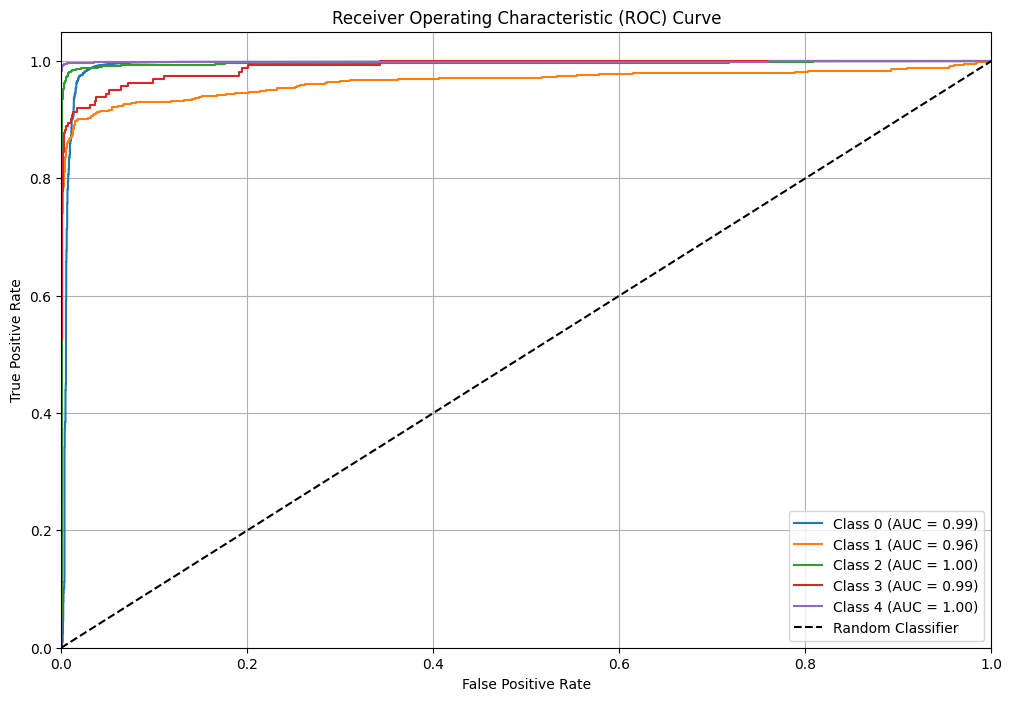

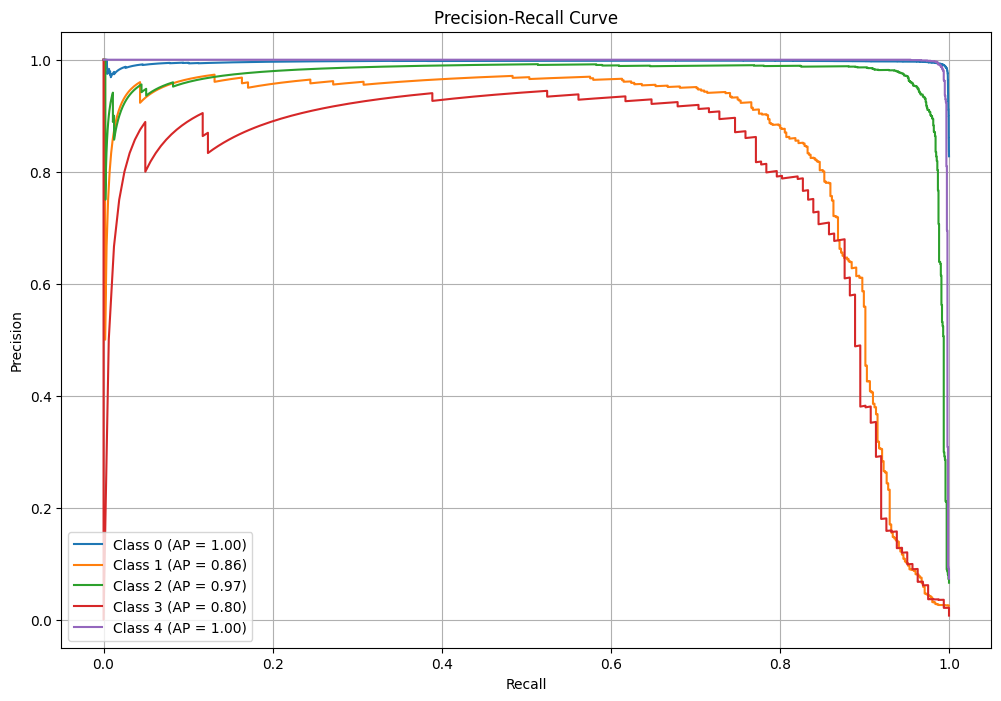

In [5]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc, precision_recall_curve, average_precision_score

n_classes = y_test.shape[1] # Number of classes

# ────────────────────────────────────────────────
# Plotting ROC Curves
# ────────────────────────────────────────────────

plt.figure(figsize=(12, 8))
for i in range(n_classes):
    fpr, tpr, _ = roc_curve(y_test[:, i], y_pred[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f'Class {i} (AUC = {roc_auc:.2f})')

plt.plot([0, 1], [0, 1], 'k--', label='Random Classifier')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

# ────────────────────────────────────────────────
# Plotting Precision-Recall Curves
# ────────────────────────────────────────────────

plt.figure(figsize=(12, 8))
for i in range(n_classes):
    precision, recall, _ = precision_recall_curve(y_test[:, i], y_pred[:, i])
    ap_score = average_precision_score(y_test[:, i], y_pred[:, i])
    plt.plot(recall, precision, label=f'Class {i} (AP = {ap_score:.2f})')

plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.legend(loc='lower left')
plt.grid(True)
plt.show()

In [6]:
# Install SHAP library if not already installed
!pip install shap -qq

In [7]:
import shap
import numpy as np
import pandas as pd
import tensorflow as tf

# Load the best model saved during training
model = tf.keras.models.load_model(
    'ecg_arrhythmia_model_final.h5',
    custom_objects={'sensitivity': sensitivity, 'specificity': specificity, 'f1_score': f1_score}
)

# For SHAP, we need a background dataset. Using a small subset of training data is common.
# Also, SHAP explainers work best with NumPy arrays.
background_signal = X_train_split[np.random.choice(X_train_split.shape[0], 100, replace=False)]
background_features = X_train_feat_split[np.random.choice(X_train_feat_split.shape[0], 100, replace=False)]

# Select a subset of test data for explanation to manage computation time
# We take a smaller sample for explanation. Let's take 100 samples from the test set.
sample_indices = np.random.choice(X_test.shape[0], 100, replace=False)
X_test_sample_signal = X_test[sample_indices]
X_test_sample_features = X_test_features[sample_indices]

# Define the prediction function for the explainer.
# It needs to accept inputs in the same format as the model's predict method.
def f(x):
    # x will be a single array, need to split it back into two inputs for the model
    # The shape of x here will be (num_samples, total_features)
    # We know signal has 187 features and handcrafted features have 6 features
    signal_input_shape = 187
    signal_data = x[:, :signal_input_shape].reshape(-1, signal_input_shape, 1)
    feature_data = x[:, signal_input_shape:]
    return model.predict([signal_data, feature_data], verbose=0)

# Combine background data into a single array for KernelExplainer
background_combined = np.hstack([background_signal.reshape(background_signal.shape[0], -1), background_features])

# Combine test sample data into a single array for KernelExplainer
test_sample_combined = np.hstack([X_test_sample_signal.reshape(X_test_sample_signal.shape[0], -1), X_test_sample_features])

# Initialize KernelExplainer. It might take some time to run.
print("Initializing SHAP KernelExplainer. This may take a moment...")
explainer = shap.KernelExplainer(f, background_combined)
print("Explainer initialized. Calculating SHAP values...")

# Calculate SHAP values
# This can be very slow for a large number of samples and features.
shap_values = explainer.shap_values(test_sample_combined)
print("SHAP values calculated.")

Initializing SHAP KernelExplainer. This may take a moment...
Explainer initialized. Calculating SHAP values...


  0%|          | 0/100 [00:00<?, ?it/s]

SHAP values calculated.



SHAP Summary Plot (Global Feature Importance):


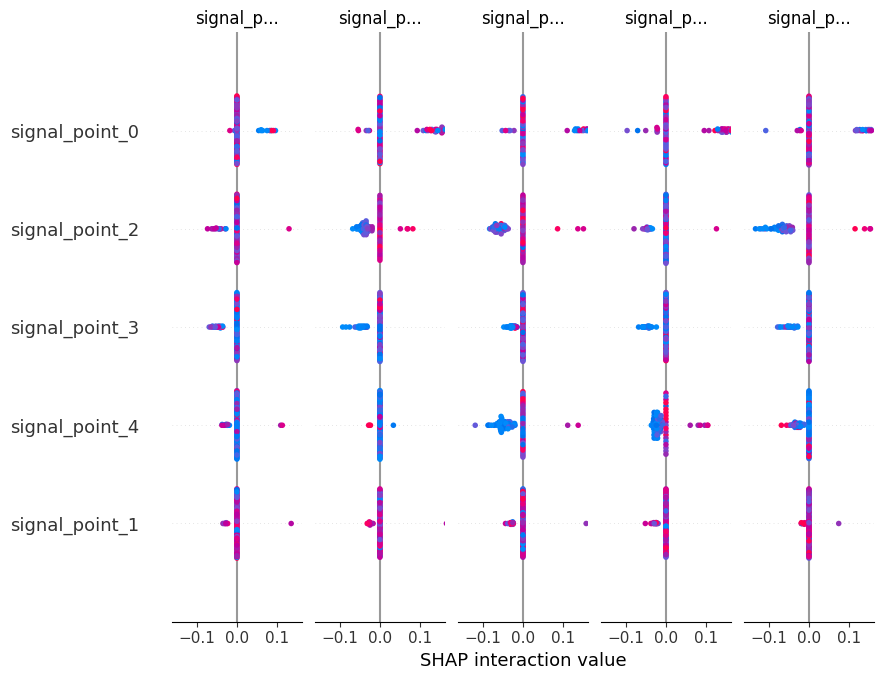


SHAP Bar Plot (Mean Absolute SHAP Value per Feature):


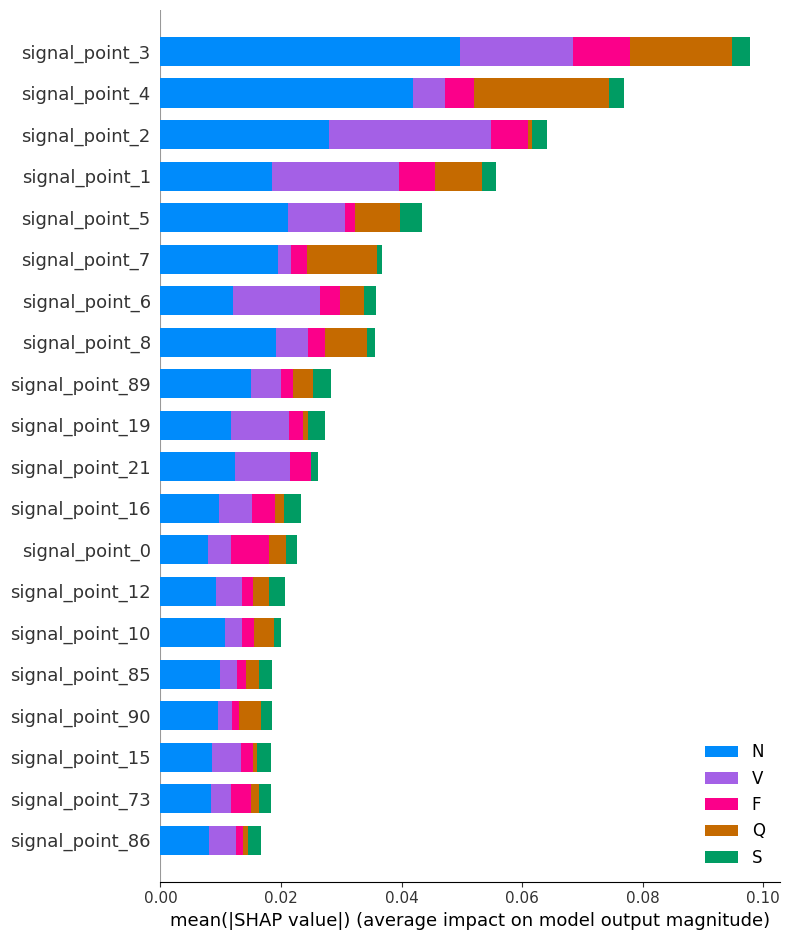


SHAP Dependence Plot for 'mean' feature (first handcrafted feature):


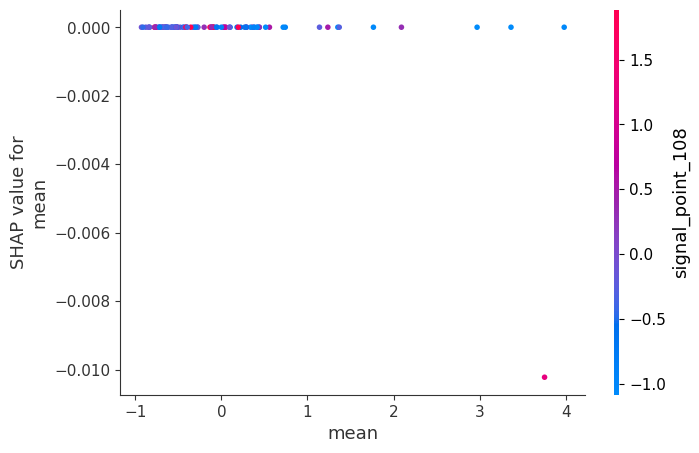

In [13]:
import matplotlib.pyplot as plt

# SHAP values are a list of arrays, one for each class
# To get an overall feature importance, we can average the absolute SHAP values across classes.
# Let's consider the shap_values for the first class (Normal class, index 0) for example.

# For visualization, we need feature names. The first 187 are signal points, the next 6 are handcrafted features.
signal_feature_names = [f'signal_point_{i}' for i in range(187)]
handcrafted_feature_names = ['mean', 'std', 'skew', 'kurtosis', 'num_peaks', 'energy']
all_feature_names = signal_feature_names + handcrafted_feature_names

# Create a dummy DataFrame for shap.summary_plot to label features correctly
X_test_sample_combined_df = pd.DataFrame(test_sample_combined, columns=all_feature_names)

print("\nSHAP Summary Plot (Global Feature Importance):")
# shap.summary_plot needs shap_values as a list if it's multi-output, or a single array
# If we want to see the impact across all classes, we can pass the list of shap_values
shap.summary_plot(shap_values, X_test_sample_combined_df, class_names=['N', 'S', 'V', 'F', 'Q'])

print("\nSHAP Bar Plot (Mean Absolute SHAP Value per Feature):")
shap.summary_plot(shap_values, X_test_sample_combined_df, plot_type="bar", class_names=['N', 'S', 'V', 'F', 'Q'])

# Visualize dependence plots for a few important features (e.g., handcrafted features)
# You can pick specific features that seem important from the summary plot
print("\nSHAP Dependence Plot for 'mean' feature (first handcrafted feature):")
# shap.dependence_plot(ind="mean", shap_values=shap_values[0], features=X_test_sample_combined_df)
shap.dependence_plot(ind="mean", shap_values=shap_values[:, :, 0], features=X_test_sample_combined_df)

The SHAP summary plot shows the distribution of SHAP values for each feature across all samples, ordered by importance. The bar plot aggregates these to show overall feature importance. The dependence plot illustrates how the value of a feature influences the prediction for a specific class, and how it interacts with other features.


CALIBRATION ANALYSIS


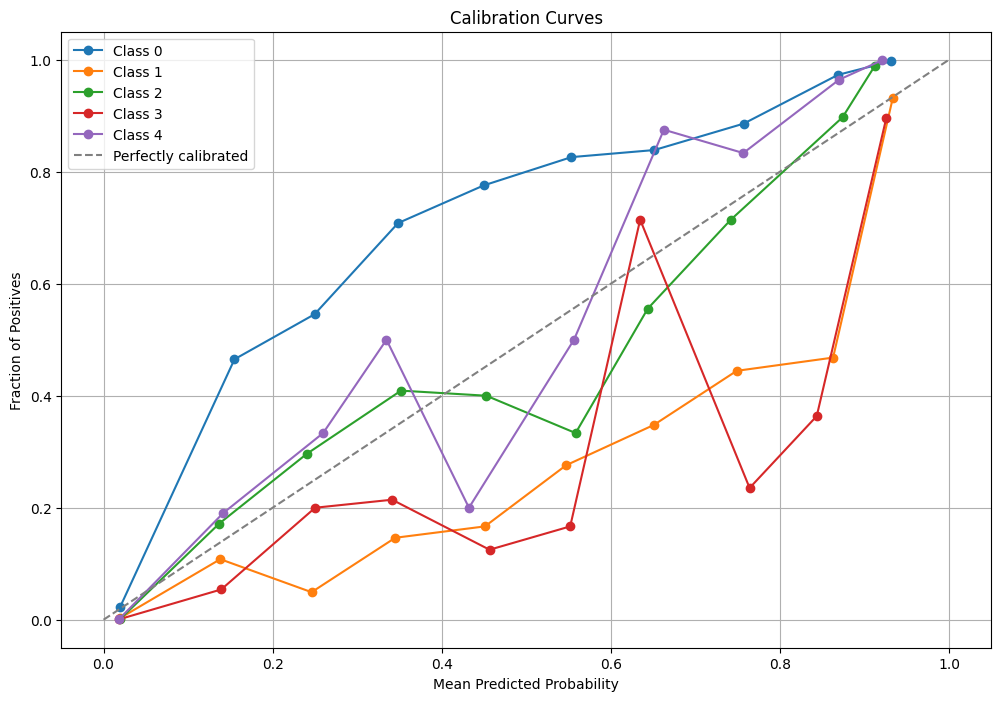

Expected Calibration Error (ECE): 0.1438


In [9]:
from sklearn.calibration import calibration_curve
from sklearn.metrics import brier_score_loss

# Function to calculate ECE (Expected Calibration Error)
def calculate_ece(y_true, y_prob, n_bins=10):
    ece = 0
    for i in range(n_classes):
        prob_true, prob_pred = calibration_curve(y_true[:, i], y_prob[:, i], n_bins=n_bins, strategy='uniform')
        bin_counts = np.histogram(y_prob[:, i], bins=n_bins, range=(0., 1.))[0]
        # Avoid division by zero for empty bins
        non_empty_bins = bin_counts > 0
        if np.any(non_empty_bins):
            ece += np.sum(bin_counts[non_empty_bins] / len(y_prob) * np.abs(prob_true[non_empty_bins] - prob_pred[non_empty_bins]))
    return ece

print("\n" + "="*50)
print("CALIBRATION ANALYSIS")
print("="*50)

# Plotting Calibration Curves
plt.figure(figsize=(12, 8))
for i in range(n_classes):
    prob_true, prob_pred = calibration_curve(y_test[:, i], y_pred[:, i], n_bins=10)
    plt.plot(prob_pred, prob_true, marker='o', label=f'Class {i}')

plt.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Perfectly calibrated')
plt.xlabel('Mean Predicted Probability')
plt.ylabel('Fraction of Positives')
plt.title('Calibration Curves')
plt.legend(loc='upper left')
plt.grid(True)
plt.show()

# Calculate ECE for all classes combined
ece_error = calculate_ece(y_test, y_pred)
print(f"Expected Calibration Error (ECE): {ece_error:.4f}")


The **Expected Calibration Error (ECE)** is a metric used to evaluate how well-calibrated a machine learning model's predicted probabilities are.

Let's break down what **ECE: 0.1438** means:

1.  **What is Calibration?**
    A model is considered well-calibrated if its predicted probabilities reflect the true likelihood of an event occurring.
    *   If a model predicts an 80% chance for 100 different instances, then ideally, approximately 80 of those instances should actually belong to the predicted class.
    *   If a model predicts a 50% chance for 100 instances, then roughly 50 of them should be correct.

2.  **How ECE is Calculated (Simplified):**
    ECE works by dividing the model's predictions into several confidence "bins" (e.g., 0-10%, 10-20%, ..., 90-100%). For each bin, it calculates:
    *   The **average confidence** of predictions falling into that bin.
    *   The **actual accuracy** (proportion of correct predictions) for samples in that bin.
    It then takes a weighted average of the absolute differences between the average confidence and the accuracy across all bins.

3.  **Meaning of the Value 0.1438:**
    *   **Range:** ECE typically ranges from 0 to 1.
    *   **0 (Zero):** A perfect ECE of 0 would mean the model is perfectly calibrated. Its predicted probabilities exactly match the true probabilities across all confidence levels.
    *   **Higher Values:** Higher ECE values indicate poorer calibration. The model's confidence in its predictions does not accurately reflect how often it is actually correct.

    Therefore, an ECE of **0.1438** means that, on average, there is a **14.38 percentage point difference** between the model's predicted confidence and its actual accuracy.

    **Example:**
    *   If the model frequently predicts 80% confidence, but for those predictions, it's only correct about 65.62% of the time (80 - 14.38), or perhaps correct 94.38% of the time (80 + 14.38), it contributes to this ECE.
    *   If the model predicts 50% confidence, but is only right about 35.62% of the time, that's another instance of miscalibration.

4.  **Is 0.1438 Good or Bad?**
    *   **Not perfectly calibrated:** It's not 0, so there's room for improvement.
    *   **Context matters:** Whether 0.1438 is "good" or "bad" heavily depends on the application:
        *   **High-stakes applications (e.g., medical diagnosis, autonomous driving):** An ECE of 0.1438 might be considered quite high, as miscalibrated confidence can lead to serious errors or lack of trust. You'd want this value to be as close to zero as possible.
        *   **Lower-stakes applications (e.g., content recommendation, spam detection):** This might be an acceptable or even good value, especially if the model achieves high accuracy otherwise.
        *   **Compared to other models:** It's often evaluated in comparison to other models or a baseline. If other models on the same task achieve 0.05, then 0.1438 is poor. If they achieve 0.30, then 0.1438 is relatively good.
    *   **General interpretation:** An ECE of 0.1438 suggests that while the model might be accurate, its reported confidence levels are not entirely trustworthy and could benefit from calibration techniques (like temperature scaling, isotonic regression, etc.) to align its probabilities with its actual performance.